In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("phase2.csv")

In [3]:
df.head()

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,18883,80,1293792,3,7,26,11607,20,0,8.666667,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
1,18884,80,4421382,4,0,24,0,6,6,6.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
2,18885,80,1083538,3,6,26,11601,20,0,8.666667,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
3,18886,80,80034360,8,4,56,11601,20,0,7.000000,...,20,939.0,0.0,939,939,39300000.0,44200000.0,70600000,8072664,DDoS
4,18887,80,642654,3,6,26,11607,20,0,8.666667,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS


In [4]:
df.columns=df.columns.str.strip()   

In [5]:
selected_feature=['Destination Port', 'Flow Duration', 'Total Length of Fwd Packets',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Fwd PSH Flags', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Mean',
       'Packet Length Std', 'FIN Flag Count', 'SYN Flag Count',
       'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio',
       'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'Active Std',
       'Idle Mean', 'Idle Std', 'Label']

In [6]:
df.shape

(288954, 80)

In [7]:
df.isna().sum()

Unnamed: 0                0
Destination Port          0
Flow Duration             0
Total Fwd Packets         0
Total Backward Packets    0
                         ..
Idle Mean                 0
Idle Std                  0
Idle Max                  0
Idle Min                  0
Label                     0
Length: 80, dtype: int64

In [8]:
df.isin([np.inf, -np.inf]).sum()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [9]:
df=df[selected_feature]


In [10]:
df.describe()

,Destination Port,Flow Duration,Total Length of Fwd Packets,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Std,...,URG Flag Count,Down/Up Ratio,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,Active Std,Idle Mean,Idle Std
count,288816.000000,2.888160e+05,2.888160e+05,288816.000000,288816.000000,288816.000000,288816.000000,2.888160e+05,2.888160e+05,2.888160e+05,...,288816.000000,288816.000000,288816.000000,288816.000000,2.888160e+05,288816.000000,288816.000000,2.888160e+05,2.888160e+05,2.888160e+05
mean,4898.149846,7.572479e+06,7.961196e+01,4.639797,3.412324,660.532897,932.872145,1.503381e+05,3.486426e+04,2.292268e+06,...,0.002462,0.827101,4.639797,660.532897,7.961196e+01,10164.811319,169.275708,2.026003e+02,5.359455e+06,1.987594e+06
std,10998.646432,2.236717e+07,9.368328e+03,50.984568,48.092229,1067.132872,1624.797532,1.043447e+06,1.007970e+05,6.021061e+06,...,0.049555,0.545739,50.984568,1067.132872,9.368328e+03,12199.191399,1707.237020,5.661952e+04,1.673606e+07,9.654288e+06
min,0.000000,1.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,3.338627e-02,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.000000,4.500000e+01,0.000000e+00,0.000000,0.000000,6.000000,0.000000,6.187185e+03,4.836186e+00,0.000000e+00,...,0.000000,1.000000,0.000000,6.000000,0.000000e+00,1024.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
50%,625.000000,7.700000e+01,2.000000e+00,2.000000,0.000000,6.000000,0.000000,1.034483e+05,2.597403e+04,0.000000e+00,...,0.000000,1.000000,2.000000,6.000000,2.000000e+00,1024.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
75%,5000.000000,1.621374e+06,2.600000e+01,7.000000,5.656854,1933.500000,1998.025400,1.632653e+05,4.444444e+04,6.299126e+05,...,0.000000,1.000000,7.000000,1933.500000,2.600000e+01,29200.000000,229.000000,0.000000e+00,0.000000e+00,0.000000e+00
max,65389.000000,1.199952e+08,2.866110e+06,5940.857143,7049.469004,5800.500000,8194.660487,3.470000e+08,2.000000e+06,6.920000e+07,...,1.000000,6.000000,5940.857143,5800.500000,2.866110e+06,64240.000000,29200.000000,2.610000e+07,1.200000e+08,6.430000e+07


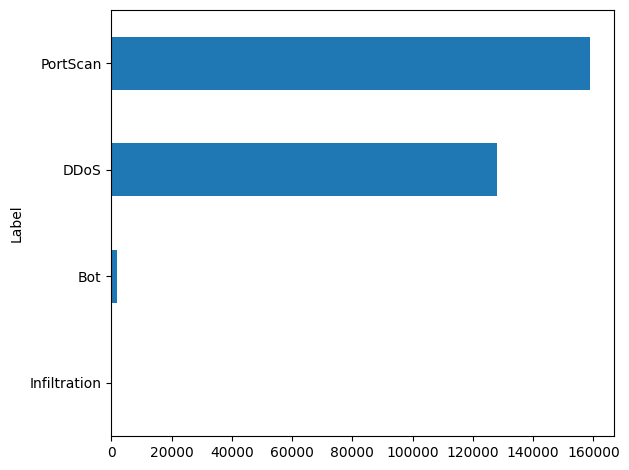

In [11]:
ax = df["Label"].value_counts(ascending=True).plot(kind="barh")
plt.tight_layout()
plt.show()

In [12]:
df["Label"].value_counts(normalize=True)*100

Label
PortScan        54.984488
DDoS            44.327530
Bot              0.677248
Infiltration     0.010733
Name: proportion, dtype: float64

In [ ]:
# df.to_csv("phase2_cleaned.csv", index=False)